# Counties (admin2) and IPC: first the whole country, then the relevant states

Read `00_guide.ipynb` first. Notes: `eda/talk/N_admin_ipc.md`.

## Why not only Jonglei and Upper Nile
That was a first zoom, not the stakeholder map. The team briefing (Yassin) and OCHA put **Unity** (Rubkona / Bentiu) next to Jonglei. Upper Nile still matters (Panyikang, Malakal). Other states can flood; we rank **all 79 counties** first, then zoom to the states that dominate unusual water.

## What we do
1. Unusual unique pixels 2022-2024, country bbox, join to every county
2. Rank counties and sum by state (who is relevant)
3. Zoom map on Jonglei + Unity + Upper Nile
4. IPC phase 3+ for those three states (context, not cause)

Sampling: if unique pixels > 100k we sample 100k. Ranks are a sample.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point

%matplotlib inline

ROOT = Path(".").resolve()
if not (ROOT / "raw_data").exists():
    ROOT = Path("..").resolve()
DATA = ROOT / "raw_data"
OUT = ROOT / "eda" / "outputs" / "admin_ipc"
OUT.mkdir(parents=True, exist_ok=True)

YEARS = [2022, 2023, 2024]
# whole country envelope, then real county polygons (not a Jonglei-only rectangle)
BBOX = {"lat_min": 3.4, "lat_max": 12.3, "lon_min": 24.1, "lon_max": 36.0}
FOCUS_STATES = ["Jonglei", "Unity", "Upper Nile"]
TILES = ["h20v08", "h21v08"]
MAX_POINTS = 100000


In [2]:
# all counties (79 + Abyei). no state filter yet
admin2 = gpd.read_file(DATA / "Administrative boundaries" / "ssd_admin2.geojson")
print("counties:", len(admin2))
print(admin2.groupby("adm1_name").size())


counties: 79
adm1_name
Abyei Region                1
Central Equatoria           6
Eastern Equatoria           8
Jonglei                    11
Lakes                       8
Northern Bahr el Ghazal     5
Unity                       9
Upper Nile                 12
Warrap                      6
Western Bahr el Ghazal      3
Western Equatoria          10
dtype: int64


In [3]:
def unusual_points(year):
    # unique locations only: counting every flood-day would inflate wetlands
    parts = []
    for tile in TILES:
        path = DATA / "flood_masks" / "compact_unusual" / f"flood_events_{tile}_{year}.parquet"
        parts.append(pd.read_parquet(path, columns=["lat", "lon"]))
    u = pd.concat(parts, ignore_index=True)
    m = (
        (u["lat"] >= BBOX["lat_min"]) & (u["lat"] <= BBOX["lat_max"]) &
        (u["lon"] >= BBOX["lon_min"]) & (u["lon"] <= BBOX["lon_max"])
    )
    u = u.loc[m, ["lon", "lat"]].drop_duplicates()
    return u.reset_index(drop=True)

all_counts = []
for year in YEARS:
    u = unusual_points(year)
    n_all = len(u)
    sampled = False
    use = u
    if n_all > MAX_POINTS:
        use = u.sample(MAX_POINTS, random_state=0)
        sampled = True
    # within = point must sit inside the county polygon
    gdf = gpd.GeoDataFrame(use, geometry=[Point(xy) for xy in zip(use["lon"], use["lat"])], crs="EPSG:4326")
    joined = gpd.sjoin(gdf, admin2[["adm1_name", "adm2_name", "geometry"]], how="inner", predicate="within")
    counts = (
        joined.groupby(["adm1_name", "adm2_name"]).size()
        .reset_index(name="unusual_unique_px")
    )
    counts["year"] = year
    counts["points_before_sample"] = n_all
    counts["sampled_down"] = sampled
    all_counts.append(counts)
    print(year, "unique_px", n_all, "used", len(use), "counties_hit", counts["adm2_name"].nunique())

counts = pd.concat(all_counts, ignore_index=True)
counts.to_csv(OUT / "admin2_unusual_2022_2024.csv", index=False)
counts.sort_values(["year", "unusual_unique_px"], ascending=[True, False]).groupby("year").head(5)

# which states carry the unusual water (sum of county unique-px in the sample)
by_state = counts.groupby(["year", "adm1_name"])["unusual_unique_px"].sum().reset_index()
by_state.to_csv(OUT / "admin1_unusual_2022_2024.csv", index=False)
print("state totals 2023:")
print(by_state[by_state.year==2023].sort_values("unusual_unique_px", ascending=False).to_string(index=False))


2022 unique_px 285378 used 100000 counties_hit 74


2023 unique_px 264400 used 100000 counties_hit 74


2024 unique_px 293983 used 100000 counties_hit 77
state totals 2023:
 year               adm1_name  unusual_unique_px
 2023                   Unity              37421
 2023                 Jonglei              32757
 2023              Upper Nile               9962
 2023                  Warrap               6532
 2023       Eastern Equatoria               3188
 2023                   Lakes               3149
 2023       Central Equatoria               1299
 2023  Western Bahr el Ghazal                445
 2023       Western Equatoria                125
 2023            Abyei Region                103
 2023 Northern Bahr el Ghazal                 61


Top counties **nationwide** each year. If Unity (Rubkona) or Canal/Pigi show up, the old Jonglei+UN-only zoom was too narrow.


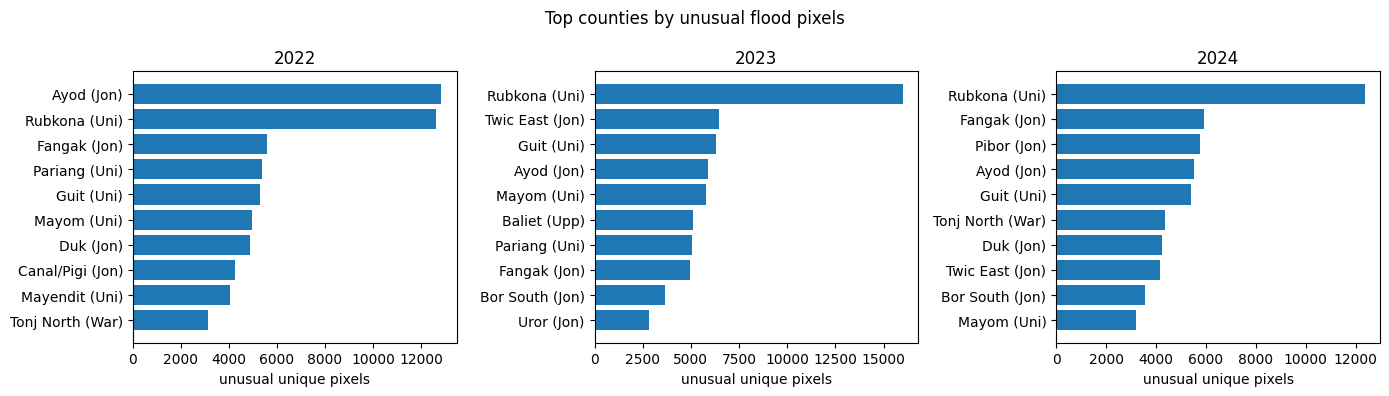

In [4]:
# reverse bars so the biggest county sits at the top
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
for ax, year in zip(axes, YEARS):
    top = counts[counts["year"]==year].sort_values("unusual_unique_px", ascending=False).head(10)
    labels = top["adm2_name"].astype(str) + " (" + top["adm1_name"].str[:3] + ")"
    ax.barh(labels[::-1], top["unusual_unique_px"][::-1])
    ax.set_title(str(year))
    ax.set_xlabel("unusual unique pixels")
fig.suptitle("Top counties by unusual flood pixels")
fig.tight_layout()
fig.savefig(OUT / "01_admin2_top_by_year.png", dpi=140)
plt.show()


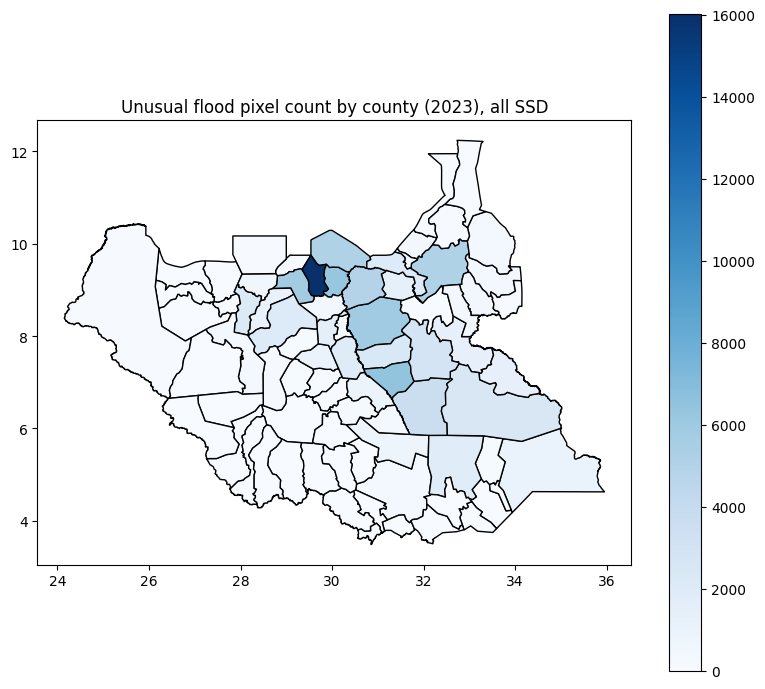

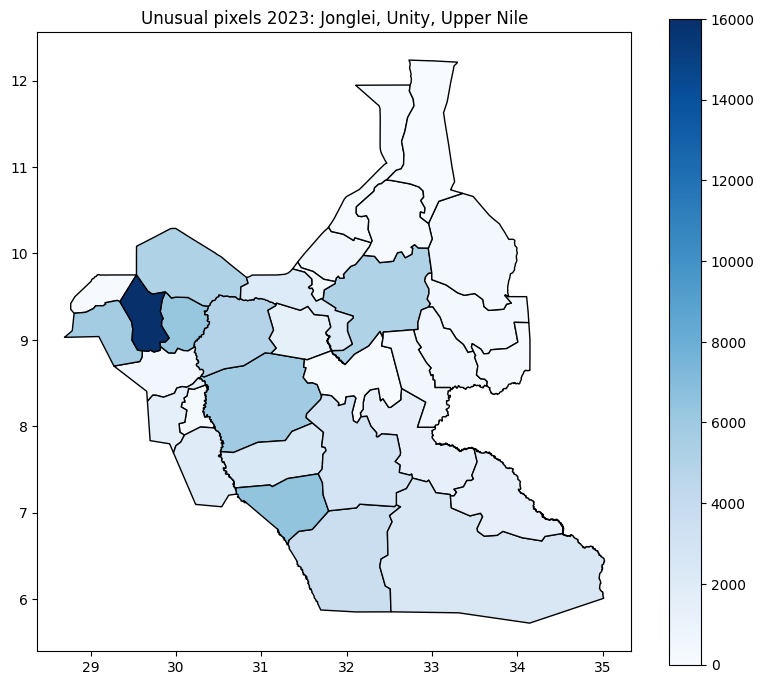

In [5]:
# 2023 only for the map so we can talk about one season in the meeting
c2023 = counts[counts["year"]==2023]
m = admin2.merge(c2023[["adm2_name", "unusual_unique_px"]], on="adm2_name", how="left")
m["unusual_unique_px"] = m["unusual_unique_px"].fillna(0)
fig, ax = plt.subplots(figsize=(8, 7))
m.plot(column="unusual_unique_px", ax=ax, legend=True, edgecolor="black", cmap="Blues")
ax.set_title("Unusual flood pixel count by county (2023), all SSD")
fig.tight_layout()
fig.savefig(OUT / "02_admin2_map_2023.png", dpi=150)
plt.show()


# zoom: the three states that should dominate unusual water
focus = m[m["adm1_name"].isin(FOCUS_STATES)]
fig, ax = plt.subplots(figsize=(8, 7))
focus.plot(column="unusual_unique_px", ax=ax, legend=True, edgecolor="black", cmap="Blues")
ax.set_title("Unusual pixels 2023: Jonglei, Unity, Upper Nile")
fig.tight_layout()
fig.savefig(OUT / "02b_focus_three_states_2023.png", dpi=150)
plt.show()


## IPC (food insecurity proxy)

Phase 3+ = crisis or worse. Sheets are few dates per year. We keep **Jonglei, Unity, Upper Nile**.

High phase 3+ is context. Not proof that floods caused hunger. Conflict and prices mix in.


In [6]:
# each excel is one IPC assessment window. we keep state rows only
rows = []
for path in sorted((DATA / "IPC").glob("IPC_SS_Acute_Food_Insecurity_*.xlsx")):
    df = pd.read_excel(path, engine="openpyxl")
    sub = df[df["Area Name"].isin(["Jonglei", "Unity", "Upper Nile"])].copy()
    sub["source_file"] = path.name
    keep = [c for c in [
        "Area Name", "Current - Est Pop", "Current - Phase 3+", "Current - Phase 3+ %",
        "Current - From Date", "Current - Thru Date", "source_file"
    ] if c in sub.columns]
    rows.append(sub[keep])
ipc = pd.concat(rows, ignore_index=True)
ipc.to_csv(OUT / "ipc_jonglei_upper_nile.csv", index=False)
ipc


,Area Name,Current - Est Pop,Current - Phase 3+,Current - Phase 3+ %,Current - From Date,Current - Thru Date,source_file
0,Jonglei,2031778,1470000,0.73,2022-02-01T00:00:00.000Z,2022-03-31T00:00:00.000Z,IPC_SS_Acute_Food_Insecurity_March_2022_2026-0...
1,Unity,1123634,759000,0.68,2022-02-01T00:00:00.000Z,2022-03-31T00:00:00.000Z,IPC_SS_Acute_Food_Insecurity_March_2022_2026-0...
2,Upper Nile,1522253,825000,0.55,2022-02-01T00:00:00.000Z,2022-03-31T00:00:00.000Z,IPC_SS_Acute_Food_Insecurity_March_2022_2026-0...
3,Jonglei,2035636,1385000,0.68,2022-10-01T00:00:00.000Z,2022-11-30T00:00:00.000Z,IPC_SS_Acute_Food_Insecurity_October_2022_2026...
4,Unity,1125769,751000,0.67,2022-10-01T00:00:00.000Z,2022-11-30T00:00:00.000Z,IPC_SS_Acute_Food_Insecurity_October_2022_2026...
5,Upper Nile,1458092,853000,0.58,2022-10-01T00:00:00.000Z,2022-11-30T00:00:00.000Z,IPC_SS_Acute_Food_Insecurity_October_2022_2026...
6,Jonglei,1031205,632000,0.61,2023-09-01T00:00:00.000Z,2023-11-30T00:00:00.000Z,IPC_SS_Acute_Food_Insecurity_September_2023_20...
7,Unity,1127192,653000,0.58,2023-09-01T00:00:00.000Z,2023-11-30T00:00:00.000Z,IPC_SS_Acute_Food_Insecurity_September_2023_20...
8,Upper Nile,813209,456000,0.56,2023-09-01T00:00:00.000Z,2023-11-30T00:00:00.000Z,IPC_SS_Acute_Food_Insecurity_September_2023_20...
9,Jonglei,2096707,1112000,0.53,2024-09-01T00:00:00.000Z,2024-11-30T00:00:00.000Z,IPC_SS_Acute_Food_Insecurity_September_2024_20...


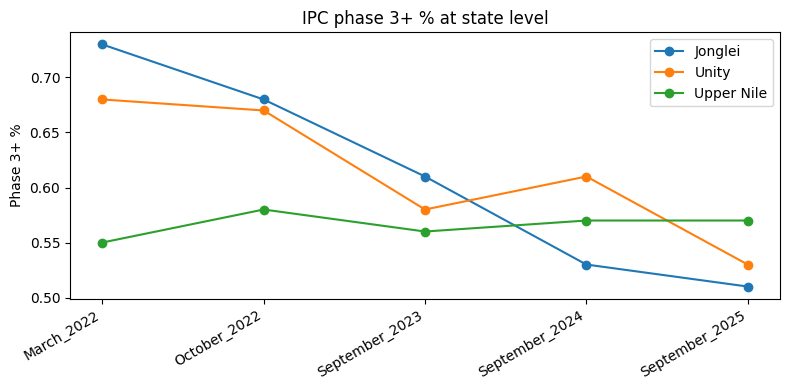

In [7]:
# x labels are file names; they are dates, not a continuous monthly series
order = sorted(ipc["source_file"].unique())
fig, ax = plt.subplots(figsize=(8, 4))
for area in ["Jonglei", "Unity", "Upper Nile"]:
    g = ipc[ipc["Area Name"]==area].drop_duplicates("source_file").set_index("source_file").reindex(order)
    ax.plot(range(len(order)), g["Current - Phase 3+ %"], marker="o", label=area)
ax.set_xticks(range(len(order)))
ax.set_xticklabels([s.replace("IPC_SS_Acute_Food_Insecurity_", "").replace("_2026-06-11.xlsx","") for s in order], rotation=30, ha="right")
ax.set_ylabel("Phase 3+ %")
ax.set_title("IPC phase 3+ % at state level")
ax.legend()
fig.tight_layout()
fig.savefig(OUT / "03_ipc_phase3plus_pct.png", dpi=140)
plt.show()
